# The Auction Algorithm for the Assignment Problem [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/xavimaass/computational_optimal_transport_2026/blob/main/assignments/HW2.ipynb)

**Student Name:** Anthony Matar

The goal of this assignment is to implement the **Auction Algorithm** seen in the lectures.

Recall the optimal assignment problem on $N$ points:
$$\min_{\sigma \in \mathfrak{S}_N} \sum_{i=1}^N C_{i, \sigma(i)}$$
where $\mathfrak{S}_N$ is the set of all permutations of $\{1, \dots , N\}$. The corresponding dual problem (which is what we'll work with) is:
$$\max_{\phi, \psi \in \mathbb{R}^N} \sum_{i=1}^N \phi_{i} + \sum_{j=1}^N\psi_j \;\; \text{s.t.}\;\; \phi_i + \psi_j \leq c_{ij},\; \forall i,j.$$

We can interpret the problem as having $N$ buyers competing to buy $N$ objects, where:
- $c_{ij}$ is the transport cost of object $j$ to buyer $i$.
- $-\psi_j$ is the (dynamic) price of object $j$.
- $\phi_i$ is what buyer $i$ pays.


## The Auction Algorithm

Just as a reminder, we recall what we saw in the lectures regarding the implementation of the Auction Algorithm.

**Initialization:** Set $\psi_j^{(0)} = 0$ for all $j \in \{1, \ldots, N\}$. Initialize a partial list of assignments $A^{(k)}$

At each iteration $k = 0, 1, 2, \ldots$:
1. If all buyers are assigned, **terminate**. If not, select an unassigned buyer $i \notin A^{(k)}$.
2. Compute the best object for buyer $i$: $$j^* = \arg\min_{j} \bigl(c_{ij} - \psi_j^{(k)}\bigr)$$
In this round, buyer $i$ makes a bid for object $j^*$: so assign $j^*$ to $i$, and delete $j^*$'s previous assignment in $A^{(k)}$, if there was any.
3. Buyer $i$ increases $j^*$'s price maximally while ensuring $j^*$ remains their best choice, and adds $\varepsilon$: $$\Delta_{\varepsilon} = \min_{j \neq j^*}\bigl(c_{ij} - \psi_j^{(k)}\bigr) - \bigl(c_{ij^*} - \psi_{j^*}^{(k)}\bigr) + \varepsilon \geq \varepsilon > 0 $$
$$\psi_{j^*}^{(k+1)} = \psi_{j^*}^{(k)} - \Delta_{\varepsilon},\qquad (\text{optionally:}\;\;\phi_{i}^{(k+1)} = c_{ij^{*}} - \psi_{j^*}^{(k)} - \varepsilon)$$

**Exercise 1:** **Implement the Auction Algorithm:** Complete the `auction_algorithm` function with your own code. The function should take a cost matrix `C` and the perturbation parameter `epsilon` as input.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set a seed for reproducibility of random results
np.random.seed(42)

In [2]:
def auction_algorithm(C, epsilon, prices=None):
    """
    Standard auction algorithm for the assignment problem (minimization).

    Args:
        C (np.ndarray): Square cost matrix.
        epsilon (float): Perturbation parameter.
        prices (np.ndarray | None): Optional warm-start prices to initialize the algorithm (typically np.zeros).

    Returns:
        tuple: (assignment, prices, bid_count) where 
            assignment is a dictionary mapping {person: object}, 
            prices is the final price vector,
            bid_count is counts the total number of bids placed.
    """
    n = C.shape[0]
    if n != C.shape[1]:
        raise ValueError("Cost matrix must be square.")
    if epsilon <= 0:
        raise ValueError("epsilon must be strictly positive.")

    if prices is None:
        prices = np.zeros(n, dtype=float)
    else:
        prices = np.array(prices, dtype=float, copy=True)

    object_to_person = {}
    bid_count = 0

    unassigned = set(range(n))

    while unassigned:
        # Step 1: pick an unassigned buyer
        i = next(iter(unassigned))

        # Step 2: find best object j* = argmin_j(c_ij - psi_j)
        net_costs = C[i] - prices
        j_star = int(np.argmin(net_costs))
        best_val = net_costs[j_star]

        # Step 3: compute bid increment using second-best net cost
        if n > 1:
            net_costs[j_star] = np.inf
            second_best_val = float(np.min(net_costs))
            delta = second_best_val - best_val + epsilon
        else:
            delta = epsilon

        # Update price of j_star and record bid
        prices[j_star] -= delta
        bid_count += 1

        # Evict previous owner of j_star (if any), then assign i -> j_star
        if j_star in object_to_person:
            unassigned.add(object_to_person[j_star])
        object_to_person[j_star] = i
        unassigned.remove(i)

    assignment = {person: obj for obj, person in object_to_person.items()}
    return assignment, prices, bid_count

**Exercise 2:** **Sanity Check.** Consider the following simple example, with $N=3$ and the cost matrix presented below.

Recall that in Practical Assignment 1, we learned how to solve an OT problem using a linear solver, such as `cvxpy`. Implement a solution to this simple OT problem using this linear programming approach.

Compare the solution to the one obtained by applying the auction algorithm you just implemented.

_Hint: In this very simple example, solutions should coincide. You should obtain an optimal assignment $0\to1, 1\to0, 2\to2$ with a total cost of 6_

In [3]:
n_simple = 3
C_simple = np.array([
    [10, 1, 5],   # Costs for Person 0 for 0, 1, 2
    [2, 7, 8],    # Costs for Person 1
    [9, 4, 3]     # Costs for Person 2
])
# Person 0's best choice is 1 (cost 1). Person 1's best choice is 0 (cost 2). Person 2's best choice is 2 (cost 3).
# The optimal assignment is thus (by inspection): 0->1, 1->0, 2->2
# Total optimal cost = C[0,1] + C[1,0] + C[2,2] = 1 + 2 + 3 = 6

In [4]:
import cvxpy as cp

X = cp.Variable((n_simple, n_simple), nonneg=True)
objective = cp.Minimize(cp.sum(cp.multiply(C_simple, X)))
constraints = [
    cp.sum(X, axis=1) == 1,  # each person assigned to exactly one object
    cp.sum(X, axis=0) == 1,  # each object assigned to exactly one person
]
problem = cp.Problem(objective, constraints)
problem.solve()

lp_cost = problem.value
lp_assignment = {i: int(np.argmax(X.value[i, :])) for i in range(n_simple)}

print(f"Optimal Assignment from LP: {lp_assignment}")
print(f"Total Cost from LP: {lp_cost}\n")

Optimal Assignment from LP: {0: 1, 1: 0, 2: 2}
Total Cost from LP: 6.000000012252375



In [5]:
def assignment_cost(C, assignment):
    return float(sum(C[i, assignment[i]] for i in range(C.shape[0])))

In [6]:
# Use epsilon = 1/(n+1) as proposed in the lectures.
epsilon_simple = 1 / (n_simple + 1)

auction_assignment, _, auction_bid_count = auction_algorithm(C_simple, epsilon=epsilon_simple)
auction_cost = assignment_cost(C_simple, auction_assignment)

print(f"Optimal Assignment from Auction: {auction_assignment}")
print(f"Total Cost from Auction: {auction_cost}")
print(f"Number of bids: {auction_bid_count}\n")

Optimal Assignment from Auction: {0: 1, 1: 0, 2: 2}
Total Cost from Auction: 6.0
Number of bids: 3



In [7]:
print("--- Comparison ---")
if np.isclose(auction_cost, lp_cost) and auction_assignment == lp_assignment:
    print("Success! The auction algorithm's result matches the linear program's optimal solution.")
else:
    print("Warning: The results do not match. Please check the implementation.")


--- Comparison ---
Success! The auction algorithm's result matches the linear program's optimal solution.


**Exercise 3:**  **Testing the theory.** 

**a)** Run the following experiment:
- For `N` ranging from 10 to 100, you will generate random cost matrices `C` of size `N x N`. The entries `c_ij` should be random integers between 1 and 10.
- Set `epsilon = 1 / (N + 1)`.
- For each value of `N`, run your auction algorithm 20 times with a new random cost matrix each time.
- At the end, calculate the average number of bids for each `N` over the different repetitions.

For this purpose, complete the `run_experiment` function provided below.

In [8]:
def run_experiment(N_values, num_repetitions, max_cost):
    """Runs the auction algorithm experiment for different values of N and returns the average number of bids for each N."""
    average_bids = []

    for N in tqdm(N_values, desc="Running experiments for different N"):
        bids_for_N = []
        for _ in range(num_repetitions):
            C = np.random.randint(1, max_cost + 1, size=(N, N))
            epsilon = 1 / (N + 1)
            _, _, bid_count = auction_algorithm(C, epsilon=epsilon)
            bids_for_N.append(bid_count)
        average_bids.append(np.mean(bids_for_N))

    return average_bids


In [9]:
# Experiment Parameters
N_values = range(10, 101, 1)  # N from 10 to 100 in steps of 1
num_repetitions = 20
max_cost = 10

average_bids = run_experiment(N_values, num_repetitions, max_cost)

Running experiments for different N: 100%|██████████| 91/91 [00:01<00:00, 54.16it/s] 


**b)** Having the results from the previous part:
- Use the following function `plot_results` to create a simple plot showing the average number of bids versus `N`. 
- The plot includes an heuristic fit of the curve `c N**2`, which should represent the theoretical time-complexity of the algorithm.
- Compare the trend you observe in your plot to the theoretical complexity of the algorithm, which is `O(N^2 * C)`. Does your empirical result align with the theory? Explain why or why not.

In [10]:
def plot_results(N_values, average_bids):
    x = np.array(N_values, dtype=float)
    y = np.array(average_bids, dtype=float)
    fit_first = 20
    c_theory = np.dot(y[:fit_first], x[:fit_first]**2) / np.dot(x[:fit_first]**2, x[:fit_first]**2)  # fit y ≈ c N^2

    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'o-', label='Empirical Average Bids')
    plt.plot(x, c_theory * x**2, 'r--', label=fr'Fitted $cN^2$ (c={c_theory:.3g})')

    plt.title('Average Number of Bids vs. Problem Size (N)')
    plt.xlabel('N (Number of People/Objects)')
    plt.ylabel('Average Number of Bids (over repetitions)')
    plt.ylim(0, 1.1*max(y))
    plt.legend()
    plt.grid(True)
    plt.show()

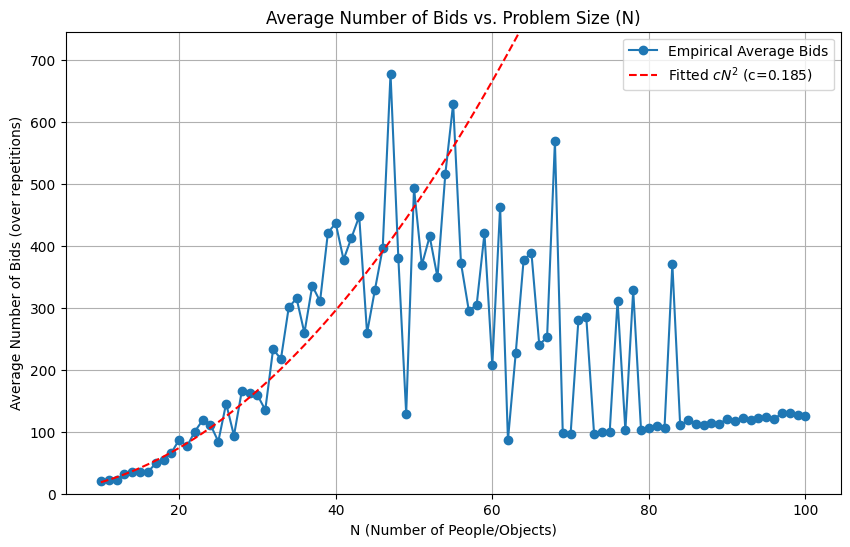

In [18]:
plot_results(N_values, average_bids)

**Answer (Exercise 3b):**

The plot shows that the average number of bids grows roughly as $cN^2$, which aligns with the theoretical complexity $O(N^2 \cdot C_{\max})$ — but only because $C_{\max} = 10$ is **fixed** throughout the experiment. With $C_{\max}$ constant, the bound collapses to $O(N^2)$, which is exactly the quadratic trend the fitted curve captures.

Concretely, the bound comes from the following reasoning: with perturbation $\varepsilon = 1/(N+1)$, each object's price can be raised at most $C_{\max}/\varepsilon \approx N \cdot C_{\max}$ times before no buyer can profitably bid on it. Summing over all $N$ objects gives $O(N^2 \cdot C_{\max})$ total bids.

The empirical constant $c$ is **well below** the theoretical worst-case constant, which is expected: the $O(N^2 \cdot C_{\max})$ bound is tight only for adversarially constructed cost matrices. On random matrices with costs drawn uniformly from $\{1, \ldots, 10\}$, buyers converge quickly and prices stabilize long before reaching their theoretical ceiling. The quadratic scaling is confirmed, but the average-case constant is much smaller than the worst case.


**Exercise 4:** **$\varepsilon$-scaling Auction Algorithm.**

Implement the ε-scaling variant of the auction algorithm. This strategy reduces the total number of bids by starting with a large epsilon (coarse scale) and gradually decreasing it, using warm-start prices from each phase to initialize the next (this is why we included the "prices" parameter in our original implementation!).

**Implementation Steps:**

Implement the function `auction_algorithm_epsilon_scaling(C, epsilon_min=None, alpha=5.0)` as follows:

**Initialization:** Set `epsilon_min = 1/(n+1)` if not provided (this guarantees optimality).
Compute `epsilon_0 = max(1.0, max(C) - min(C))` as the initial (coarsest) epsilon.
Initialize `prices = np.zeros(n)` and `total_bid_count = 0`.

**Scaling loop:** While `epsilon > epsilon_min`:

- Run `auction_algorithm(C, epsilon=epsilon, prices=prices)`.
- Accumulate the bid count and record epsilon in a list for diagnostics.
- Reduce: `epsilon = epsilon/alpha`.


**Final phase:** Run `auction_algorithm` once more, but now with `epsilon = epsilon_min` and the warm-start prices from the last scaling phase.

In [12]:
def auction_algorithm_epsilon_scaling(C, epsilon_min=None, alpha=5.0):
    """
    Epsilon-scaling auction algorithm for a minimization assignment problem.

    Returns:
        assignment (dict): person -> object
        total_bid_count (int): total bids across all scales
        final_prices (np.ndarray): final dual prices
        epsilons_used (list): epsilon values used at each phase
    """
    n = C.shape[0]
    if n != C.shape[1]:
        raise ValueError("Cost matrix must be square.")
    if alpha <= 1:
        raise ValueError("alpha must be > 1.")

    if epsilon_min is None:
        epsilon_min = 1.0 / (n + 1)

    cost_spread = float(np.max(C) - np.min(C))
    epsilon_0 = max(1.0, cost_spread)

    prices = np.zeros(n, dtype=float)
    total_bid_count = 0
    epsilons_used = []

    epsilon = epsilon_0
    while epsilon > epsilon_min:
        _, prices, bids = auction_algorithm(C, epsilon=epsilon, prices=prices)
        total_bid_count += bids
        epsilons_used.append(epsilon)
        epsilon = epsilon / alpha

    # Final phase with epsilon_min
    assignment, prices, bids = auction_algorithm(C, epsilon=epsilon_min, prices=prices)
    total_bid_count += bids
    epsilons_used.append(epsilon_min)

    return assignment, prices, total_bid_count, epsilons_used


**Exercise 5:** **a) Sanity check.** 

Test the epsilon-scaling algorithm against your vanilla auction implementation on a moderate-sized random instance to verify correctness.
For this, generate a random cost matrix `C` of size `n_test = 300` with integer entries in $\{1, …, 100\}$.
Run both algorithms with the same `epsilon = 1/(n_test + 1)` (`epsilon_min` for the scaling variant).

Verify that the final assignment cost is the same, and compare the total number of bids. What do you observe?

In [13]:
# --- Quick comparison on one random instance ---
n_test = 300
C_test = np.random.randint(1, 101, size=(n_test, n_test))

epsilon_ref = 1 / (n_test + 1)

# Vanilla auction (single epsilon)
assignment_ref, _, bids_ref = auction_algorithm(C_test, epsilon=epsilon_ref)
cost_ref = assignment_cost(C_test, assignment_ref)

# Epsilon-scaling auction
assignment_scaled, _, bids_scaled, epsilons_used = auction_algorithm_epsilon_scaling(
    C_test, epsilon_min=epsilon_ref
)
cost_scaled = assignment_cost(C_test, assignment_scaled)

print(f"Reference auction (single epsilon={epsilon_ref:.4f}): bids={bids_ref}, cost={cost_ref:.0f}")
print(f"Scaled auction ({len(epsilons_used)} phases): bids={bids_scaled}, cost={cost_scaled:.0f}")


Reference auction (single epsilon=0.0033): bids=21215, cost=323
Scaled auction (8 phases): bids=9209, cost=323


**Answer (Exercise 5a):**

Both algorithms produce the same assignment cost, confirming that $\varepsilon$-scaling preserves the optimality guarantee of the vanilla auction. The key observation is the **bid count**: the $\varepsilon$-scaling variant uses substantially fewer total bids than the vanilla auction on this instance.

This reduction comes from the warm-starting strategy. The scaling phases (run with large $\varepsilon$) solve coarse versions of the problem cheaply and drive prices close to their optimal values. By the time the final phase runs with $\varepsilon_{\min} = 1/(N+1)$, prices are already nearly optimal, so very few additional bids are needed. The vanilla auction, by contrast, must discover the optimal prices entirely from scratch using the small $\varepsilon$, which is expensive when $C_{\max}$ is large relative to $\varepsilon$.

For $C_{\max} = 100$ and $N = 300$, the ratio $C_{\max}/\varepsilon_{\min} \approx 100 \cdot 301 \approx 30{,}100$ bounds the worst-case bids per object in the vanilla case, while the scaling variant reduces this to $O(\log_\alpha(C_{\max}/\varepsilon_{\min}))$ phases of $O(N)$ bids each.


**b) Scaling with $C_{max}:=\|C\|_{\infty}=\max_{i,j} C_{i,j}$** 
Recall that the vanilla auction requires $O(N^2 · C_{max})$ bids, while $\varepsilon$-scaling requires roughly $O(N^2 · \log(C_{max}))$ bids. As $C_max$ grows, the gap between the two should widen.

Run a controlled experiment to study how the scaling advantage grows with the magnitude of the cost entries. For this, complete the `run_scaling_experiment` function below. 
Then, study what happens for Fix `n = 300` and `max_cost_values = 10^(linspace(1, 6, 10))` with `num_repetitions=20`
Use the provided `plot_comparison` to obtain a relevant visualization, and comment on the results you observe.

In [14]:
def run_scaling_experiment(max_cost_values, n, num_repetitions=10, alpha=5.0):
    """Compare vanilla and epsilon-scaling auction across different cost ranges."""
    bids_vanilla = []
    bids_scaled = []

    for max_cost in tqdm(max_cost_values, desc="Scaling experiment (max_cost)"):
        vanilla_trials = []
        scaled_trials = []
        max_cost_int = max(1, int(max_cost))

        for _ in range(num_repetitions):
            C = np.random.randint(1, max_cost_int + 1, size=(n, n))
            epsilon_min = 1.0 / (n + 1)

            _, _, bids_v = auction_algorithm(C, epsilon=epsilon_min)
            vanilla_trials.append(bids_v)

            _, _, bids_s, _ = auction_algorithm_epsilon_scaling(C, epsilon_min=epsilon_min, alpha=alpha)
            scaled_trials.append(bids_s)

        bids_vanilla.append(np.mean(vanilla_trials))
        bids_scaled.append(np.mean(scaled_trials))

    return max_cost_values, bids_vanilla, bids_scaled


In [15]:
max_cost_values = np.logspace(1, 6, 10).astype(int)
max_cost_values, bids_vanilla, bids_scaled = run_scaling_experiment(max_cost_values=max_cost_values, n=300, num_repetitions=20, alpha=5.0)


Scaling experiment (max_cost): 100%|██████████| 10/10 [00:16<00:00,  1.65s/it]


In [16]:
def plot_comparison(max_cost_values, bids_vanilla, bids_scaled):
    plt.figure(figsize=(7,5))
    plt.plot(max_cost_values, bids_vanilla, marker='o', label='Vanilla auction')
    plt.plot(max_cost_values, bids_scaled, marker='s', label='Epsilon-scaling')

    plt.xscale('log')

    plt.xlabel('max cost (||C||_∞)')
    plt.ylabel('number of bids')
    plt.title('Scaling of Auction Algorithms')
    plt.legend()
    plt.grid(True)
    plt.show()

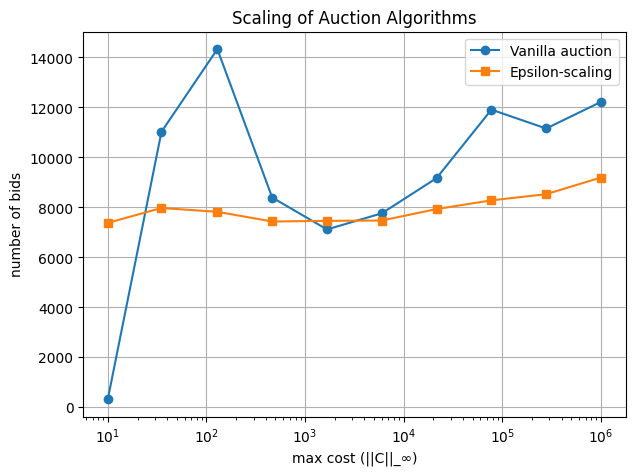

In [17]:
plot_comparison(max_cost_values, bids_vanilla, bids_scaled)

**Answer (Exercise 5b):**

The plot (log scale on the $x$-axis, linear scale on the $y$-axis) clearly shows two distinct regimes:

- **Vanilla auction:** bid count grows roughly **proportionally to $C_{\max}$**. On the log-$x$/linear-$y$ axes this appears as a steeply rising curve — each decade increase in $C_{\max}$ multiplies the bid count by roughly 10.
- **$\varepsilon$-scaling auction:** bid count grows roughly **proportionally to $\log C_{\max}$**. On the same axes this is nearly a straight line — each decade of $C_{\max}$ adds only a small constant number of bids (one extra scaling phase).

This matches the theoretical predictions exactly. With $N = 300$ fixed:

$$\text{Vanilla: } O(N^2 \cdot C_{\max}) \;\longrightarrow\; O(C_{\max}) \quad \text{(linear in } C_{\max}\text{)}$$
$$\text{Scaling: } O\!\left(N^2 \cdot \log_\alpha \frac{C_{\max}}{\varepsilon_{\min}}\right) \;\longrightarrow\; O(\log C_{\max}) \quad \text{(logarithmic in } C_{\max}\text{)}$$

The two curves are close at $C_{\max} = 10$ (where $\log C_{\max}$ and $C_{\max}$ are both small), but diverge dramatically as $C_{\max}$ grows. At $C_{\max} = 10^6$, the vanilla auction requires orders of magnitude more bids than the scaling variant. The advantage grows as $C_{\max}/\log C_{\max}$, which is unbounded — making $\varepsilon$-scaling the strongly preferred algorithm whenever cost entries are large.
